In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
sns.set_palette("husl")

In [ ]:
# ============================================================
# Carregar do Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
#
# # Ajuste o caminho abaixo conforme a localização do arquivo no seu Drive
filepath = "/content/drive/MyDrive/Case SKU/data/base-de-dados.csv"
df = pd.read_csv(filepath, thousands=".")
print(f"Dados carregados com sucesso: {df.shape[0]} linhas x {df.shape[1]} colunas")

Mounted at /content/drive
Dados carregados com sucesso: 126781 linhas x 22 colunas


In [ ]:
cols_object = df.select_dtypes(include=["object"]).columns.tolist()
cols_excluir = ["sk_produto_case", "cod_canal_portfolio", "des_categoria_portfolio",
                "des_status_atual_agrup"]

for col in cols_object:
    if col not in cols_excluir:
        amostra = df[col].dropna().head(100).astype(str)
        padrao_numerico = amostra.str.match(r"^[\d\s\.\,\-\+R\$%]+$")
        if padrao_numerico.mean() > 0.7:
            serie_limpa = (
                df[col].astype(str).str.strip()
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df[col] = pd.to_numeric(serie_limpa, errors="coerce")

In [ ]:
# ============================================================
# TRAJETÓRIA E DISTÂNCIA DO PICO - SOMENTE PRODUTOS INATIVOS
# ============================================================

# Preparação
ciclos_ordenados = sorted(df["cod_ciclo"].unique())
mapa_ciclo = {ciclo: idx for idx, ciclo in enumerate(ciclos_ordenados)}
df["ordem_ciclo"] = df["cod_ciclo"].map(mapa_ciclo)

df_sorted = df.sort_values(["sk_produto_case", "ordem_ciclo"])

df_inativos = df_sorted[df_sorted["des_status_atual_agrup"] == "Inativo"].copy()

# Pico histórico
df_inativos["pico_historico"] = (
    df_inativos.groupby("sk_produto_case")["ind_vlr_receita_real_dia_corrigido"]
    .transform(lambda x: x.expanding().max())
)

# % do pico
df_inativos["pct_pico"] = (
    df_inativos["ind_vlr_receita_real_dia_corrigido"] /
    df_inativos["pico_historico"].replace(0, np.nan)
) * 100

# Ciclos desde o pico
def calc_ciclos_desde_pico(serie):
    resultado = []
    pico_val = -np.inf
    ciclo_pico = 0
    for i, val in enumerate(serie):
        if val >= pico_val:
            pico_val = val
            ciclo_pico = i
        resultado.append(i - ciclo_pico)
    return pd.Series(resultado, index=serie.index)

df_inativos["ciclos_desde_pico"] = (
    df_inativos.groupby("sk_produto_case")["ind_vlr_receita_real_dia_corrigido"]
    .transform(calc_ciclos_desde_pico)
)

# Eixo relativo ao fim
ultimo_ciclo = df_inativos.groupby("sk_produto_case")["ordem_ciclo"].max().reset_index(name="ordem_ultimo")
df_inativos = df_inativos.merge(ultimo_ciclo, on="sk_produto_case", how="left")
df_inativos["ciclos_antes_ultimo"] = df_inativos["ordem_ciclo"] - df_inativos["ordem_ultimo"]

n_inativos = df_inativos["sk_produto_case"].nunique()
print(f"Produtos Inativos: {n_inativos}")

Produtos Inativos: 1544


1. TRAJETÓRIA DO % DO PICO (Produtos Inativos)


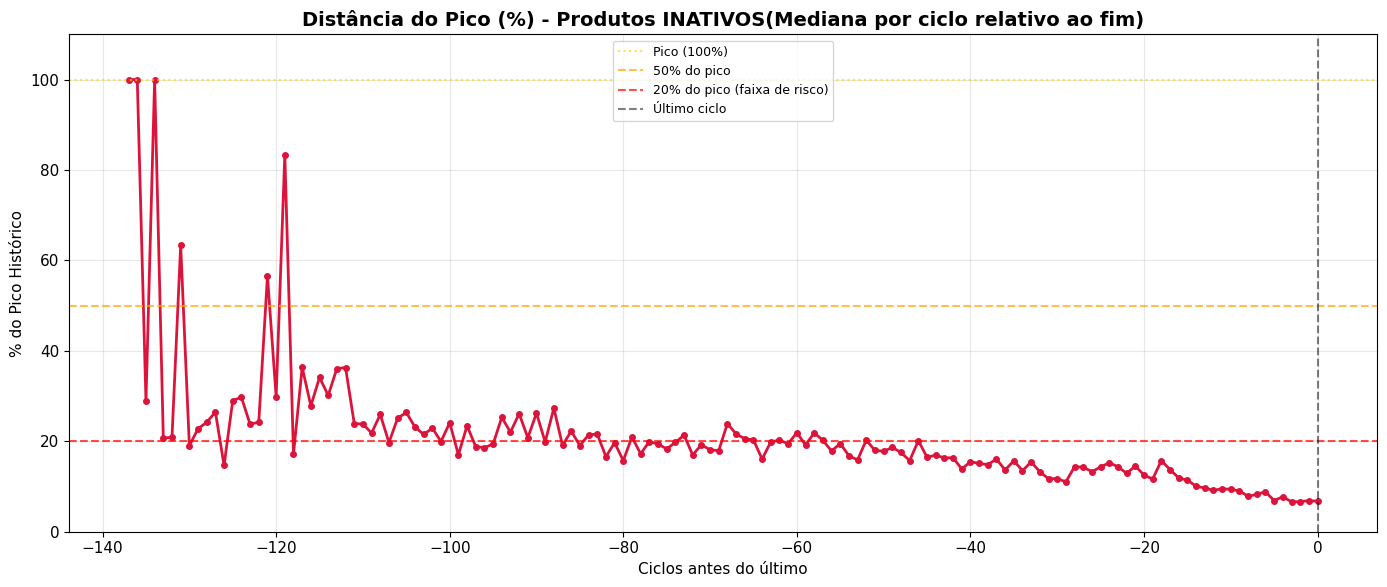

In [ ]:
# ============================================================
# 1. TRAJETÓRIA DO % DO PICO (Produtos Inativos)
# ============================================================

print(f"{'='*60}")
print("1. TRAJETÓRIA DO % DO PICO (Produtos Inativos)")
print(f"{'='*60}")

traj_pico = (
    df_inativos.groupby("ciclos_antes_ultimo")["pct_pico"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    traj_pico["ciclos_antes_ultimo"],
    traj_pico["pct_pico"],
    marker="o",
    markersize=4,
    linewidth=2,
    color="crimson",
)
plt.axhline(100, linestyle=":", color="gold", alpha=0.7, label="Pico (100%)")
plt.axhline(50, linestyle="--", color="orange", alpha=0.7, label="50% do pico")
plt.axhline(20, linestyle="--", color="red", alpha=0.7, label="20% do pico (faixa de risco)")
plt.axvline(0, linestyle="--", color="black", alpha=0.5, label="Último ciclo")
plt.title("Distância do Pico (%) - Produtos INATIVOS(Mediana por ciclo relativo ao fim)", fontsize=14, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("% do Pico Histórico")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()


2. TEMPO DESDE O PICO (Produtos Inativos)


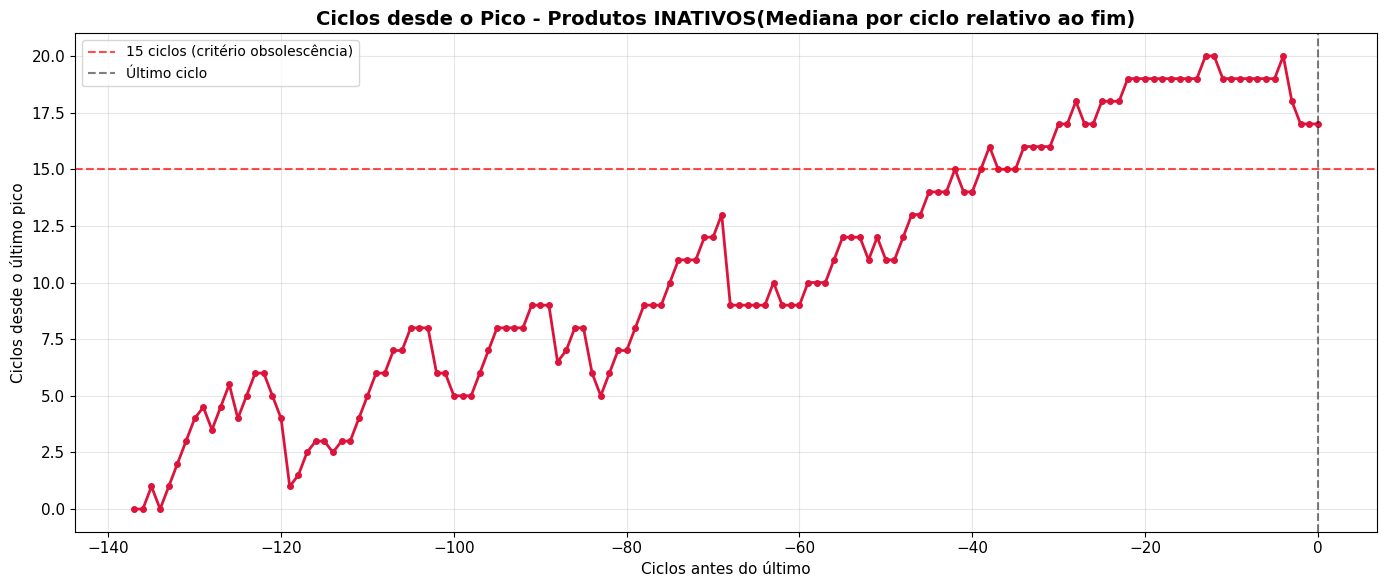

In [ ]:
# ============================================================
# 2. TEMPO DESDE O PICO (Produtos Inativos)
# ============================================================

print(f"{'='*60}")
print("2. TEMPO DESDE O PICO (Produtos Inativos)")
print(f"{'='*60}")

traj_tempo = (
    df_inativos.groupby("ciclos_antes_ultimo")["ciclos_desde_pico"]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(
    traj_tempo["ciclos_antes_ultimo"],
    traj_tempo["ciclos_desde_pico"],
    marker="o",
    markersize=4,
    linewidth=2,
    color="crimson",
)
plt.axhline(15, linestyle="--", color="red", alpha=0.7, label="15 ciclos (critério obsolescência)")
plt.axvline(0, linestyle="--", color="black", alpha=0.5, label="Último ciclo")
plt.title("Ciclos desde o Pico - Produtos INATIVOS(Mediana por ciclo relativo ao fim)", fontsize=14, fontweight="bold")
plt.xlabel("Ciclos antes do último")
plt.ylabel("Ciclos desde o último pico")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


3. DISTRIBUIÇÃO DO % DO PICO - ÚLTIMO CICLO (Inativos)


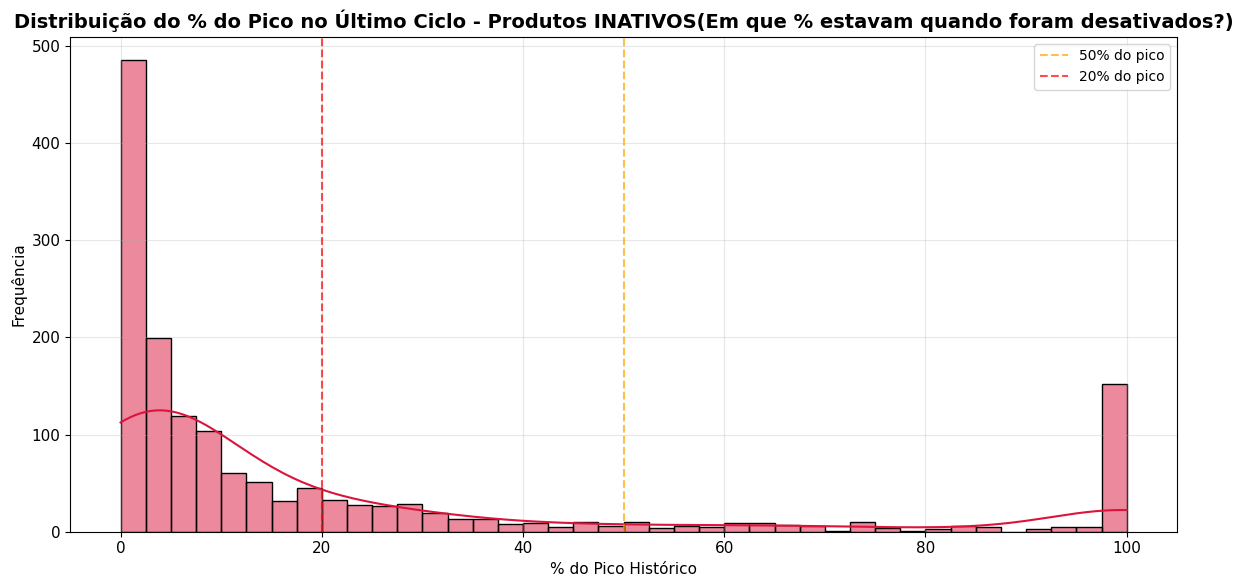

--- Estatísticas (% do pico no último ciclo) ---
  Mediana: 6.7%
  Média:   21.8%
  Abaixo de 50%: 83.7% dos inativos
  Abaixo de 20%: 70.9% dos inativos


In [ ]:
# ============================================================
# 3. DISTRIBUIÇÃO DO % DO PICO NO ÚLTIMO CICLO (Inativos)
# ============================================================

print(f"{'='*60}")
print("3. DISTRIBUIÇÃO DO % DO PICO - ÚLTIMO CICLO (Inativos)")
print(f"{'='*60}")

df_ultimo_inativos = df_inativos[df_inativos["ciclos_antes_ultimo"] == 0]

plt.figure(figsize=(12, 6))
sns.histplot(df_ultimo_inativos["pct_pico"], bins=40, kde=True, color="crimson")
plt.axvline(50, linestyle="--", color="orange", alpha=0.7, label="50% do pico")
plt.axvline(20, linestyle="--", color="red", alpha=0.7, label="20% do pico")
plt.title("Distribuição do % do Pico no Último Ciclo - Produtos INATIVOS(Em que % estavam quando foram desativados?)", fontsize=14, fontweight="bold")
plt.xlabel("% do Pico Histórico")
plt.ylabel("Frequência")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"--- Estatísticas (% do pico no último ciclo) ---")
print(f"  Mediana: {df_ultimo_inativos['pct_pico'].median():.1f}%")
print(f"  Média:   {df_ultimo_inativos['pct_pico'].mean():.1f}%")
print(f"  Abaixo de 50%: {(df_ultimo_inativos['pct_pico'] < 50).mean()*100:.1f}% dos inativos")
print(f"  Abaixo de 20%: {(df_ultimo_inativos['pct_pico'] < 20).mean()*100:.1f}% dos inativos")


4. DISTRIBUIÇÃO CICLOS DESDE O PICO - ÚLTIMO CICLO (Inativos)


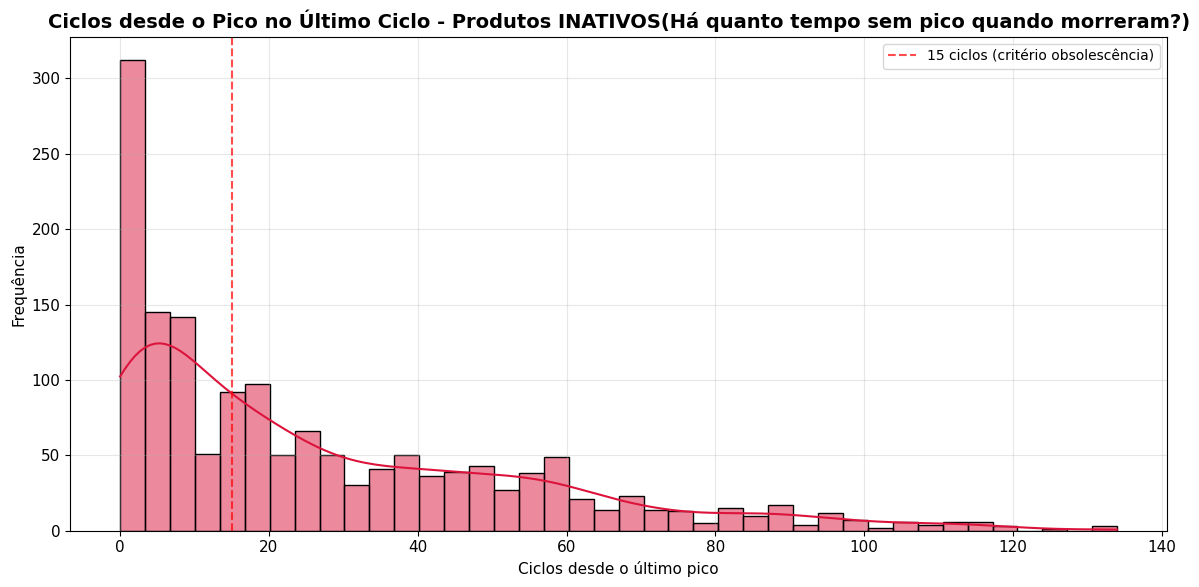

--- Estatísticas (ciclos desde pico) ---
  Mediana: 17 ciclos
  Média:   27 ciclos
  >= 15 ciclos: 56.3% dos inativos


In [ ]:
# ============================================================
# 4. DISTRIBUIÇÃO DE CICLOS DESDE O PICO (Inativos)
# ============================================================

print(f"{'='*60}")
print("4. DISTRIBUIÇÃO CICLOS DESDE O PICO - ÚLTIMO CICLO (Inativos)")
print(f"{'='*60}")

plt.figure(figsize=(12, 6))
sns.histplot(df_ultimo_inativos["ciclos_desde_pico"], bins=40, kde=True, color="crimson")
plt.axvline(15, linestyle="--", color="red", alpha=0.7, label="15 ciclos (critério obsolescência)")
plt.title("Ciclos desde o Pico no Último Ciclo - Produtos INATIVOS(Há quanto tempo sem pico quando morreram?)", fontsize=14, fontweight="bold")
plt.xlabel("Ciclos desde o último pico")
plt.ylabel("Frequência")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"--- Estatísticas (ciclos desde pico) ---")
print(f"  Mediana: {df_ultimo_inativos['ciclos_desde_pico'].median():.0f} ciclos")
print(f"  Média:   {df_ultimo_inativos['ciclos_desde_pico'].mean():.0f} ciclos")
print(f"  >= 15 ciclos: {(df_ultimo_inativos['ciclos_desde_pico'] >= 15).mean()*100:.1f}% dos inativos")


5. EM QUE FAIXA OS PRODUTOS MORRERAM?


,Quantidade,Percentual (%)
faixa_pico,,
0-20% (CRÍTICO),1095,70.9
20-40% (Baixo),168,10.9
40-60% (MÉDIO),55,3.6
60-80% (MODERADO),47,3.0
80-100% (SAUDÁVEL),179,11.6
>100% (NO PICO),0,0.0


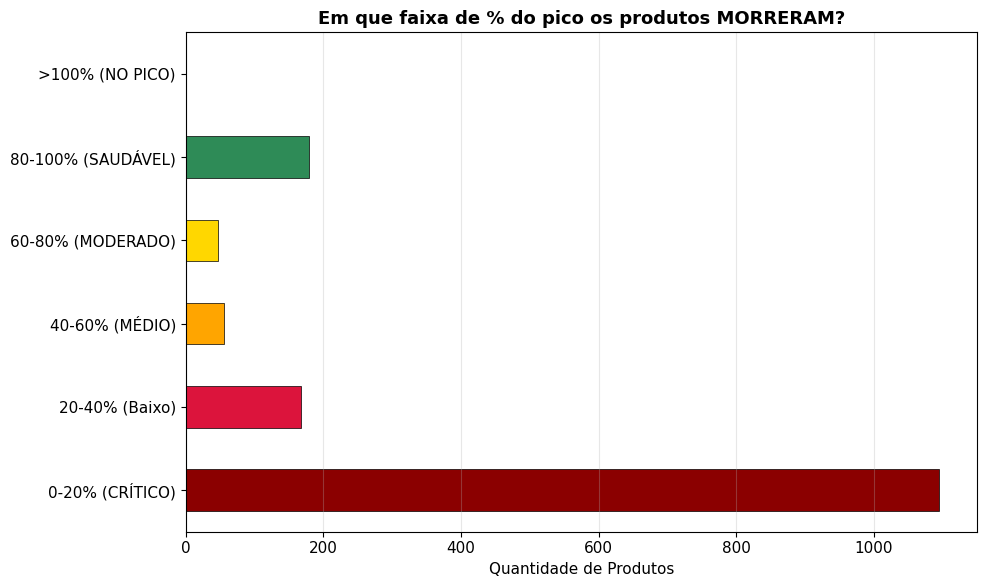

In [ ]:
# ============================================================
# 5. FAIXAS: Em que % do pico os produtos MORRERAM
# ============================================================

print(f"{'='*60}")
print("5. EM QUE FAIXA OS PRODUTOS MORRERAM?")
print(f"{'='*60}")

df_ultimo_inativos["faixa_pico"] = pd.cut(
    df_ultimo_inativos["pct_pico"],
    bins=[0, 20, 40, 60, 80, 100, 200],
    labels=["0-20% (CRÍTICO)", "20-40% (Baixo)", "40-60% (MÉDIO)", "60-80% (MODERADO)", "80-100% (SAUDÁVEL)", ">100% (NO PICO)"],
)

faixa_contagem = df_ultimo_inativos["faixa_pico"].value_counts().sort_index()
faixa_pct = (df_ultimo_inativos["faixa_pico"].value_counts(normalize=True) * 100).sort_index()

resumo_faixas = pd.DataFrame({
    "Quantidade": faixa_contagem,
    "Percentual (%)": faixa_pct.round(1),
})
display(resumo_faixas)

plt.figure(figsize=(10, 6))
cores = ["darkred", "crimson", "orange", "gold", "seagreen", "darkgreen"]
faixa_contagem.plot(kind="barh", color=cores, edgecolor="black", linewidth=0.5)
plt.title("Em que faixa de % do pico os produtos MORRERAM?", fontsize=13, fontweight="bold")
plt.xlabel("Quantidade de Produtos")
plt.ylabel("")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()